<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/underfitting_overfitting_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Understanding Overfitting and Underfitting

In this notebook, we will explore the concepts of **Underfitting (High Bias)** and **Overfitting (High Variance)** using Polynomial Regression.

* **Underfitting:** The model is too simple to capture the underlying patterns of the data. It performs poorly on both training and test data.
* **Good Fit:** The model captures the underlying pattern without capturing the noise. It performs well on both training and test data.
* **Overfitting:** The model is too complex and memorizes the training data (including its noise). It performs perfectly on training data but poorly on unseen test data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')

### 1. Generating a Synthetic Dataset
Let's create a non-linear dataset. We will use a true sine wave function and add some random noise to represent real-world data.

In [ ]:
np.random.seed(42)

# The true function (a sine wave)
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# Generate random data points
n_samples = 40
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1 # Add noise

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 28
Testing samples: 12


### 2. Training Models and Visualizing Results
We will train three models with varying levels of complexity:
1.  **Degree 1 (Linear Regression):** Too simple.
2.  **Degree 4 (Polynomial):** Just right.
3.  **Degree 15 (Polynomial):** Too complex.

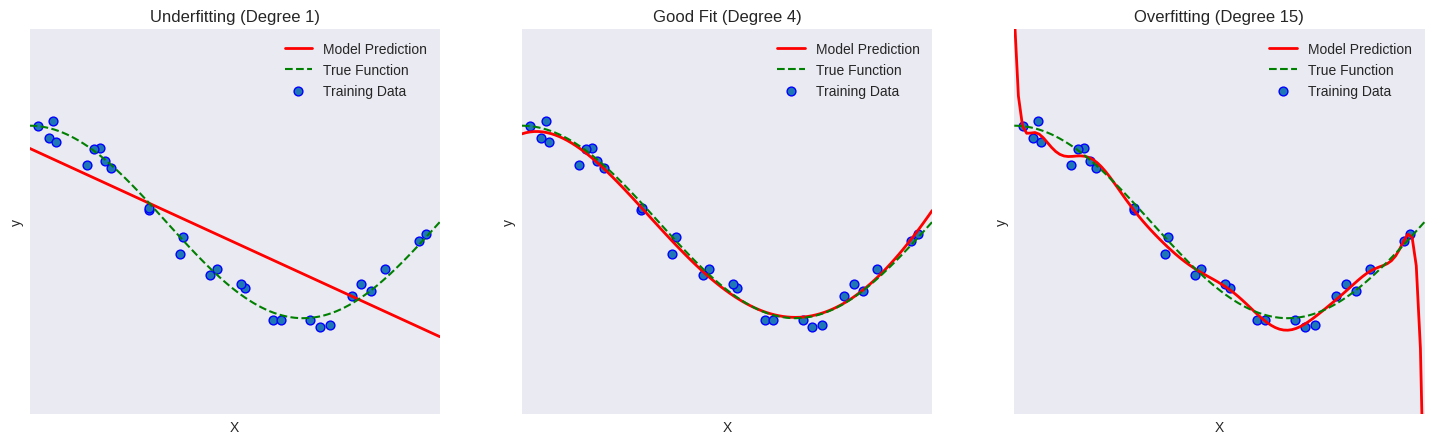

In [ ]:
degrees = [1, 4, 15]
titles = ['Underfitting (Degree 1)', 'Good Fit (Degree 4)', 'Overfitting (Degree 15)']

plt.figure(figsize=(18, 5))

for i in range(len(degrees)):
    ax = plt.subplot(1, 3, i + 1)
    plt.setp(ax, xticks=(), yticks=())

    # Create a pipeline that creates polynomial features, then fits linear regression
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression)
    ])

    # Reshape X for sklearn
    X_train_reshaped = X_train[:, np.newaxis]
    pipeline.fit(X_train_reshaped, y_train)

    # Evaluate the models
    X_test_reshaped = np.linspace(0, 1, 100)[:, np.newaxis]

    # Plot the true function, the model, and the training data
    plt.plot(X_test_reshaped, pipeline.predict(X_test_reshaped), label="Model Prediction", color="red", linewidth=2)
    plt.plot(X_test_reshaped, true_fun(X_test_reshaped), label="True Function", color="green", linestyle="--")
    plt.scatter(X_train, y_train, edgecolor='b', s=40, label="Training Data")

    plt.xlabel("X")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title(f"{titles[i]}")

plt.show()

### 3. Evaluating Error (The Math Behind the Pictures)
Visuals are great, but in machine learning, we use metrics. Let's look at the **Mean Squared Error (MSE)** for the Training set vs. the Test set.

* **Underfitting:** High Train Error, High Test Error.
* **Good Fit:** Low Train Error, Low Test Error.
* **Overfitting:** Extremely Low Train Error (it memorized the data!), but High Test Error.

In [ ]:
for i, degree in enumerate(degrees):
    # Build and fit the model
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    lin_reg = LinearRegression()
    pipeline = Pipeline([("poly_features", poly_features), ("lin_reg", lin_reg)])

    X_train_re = X_train[:, np.newaxis]
    X_test_re = X_test[:, np.newaxis]

    pipeline.fit(X_train_re, y_train)

    # Predict on Train and Test sets
    train_preds = pipeline.predict(X_train_re)
    test_preds = pipeline.predict(X_test_re)

    # Calculate MSE
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)

    print(f"--- Model: {titles[i]} ---")
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test MSE:  {test_mse:.4f}\n")

--- Model: Underfitting (Degree 1) ---
Train MSE: 0.1725
Test MSE:  0.2597

--- Model: Good Fit (Degree 4) ---
Train MSE: 0.0072
Test MSE:  0.0075

--- Model: Overfitting (Degree 15) ---
Train MSE: 0.0040
Test MSE:  0.0157



### 💡 Key Takeaways
1. **High Bias (Underfitting)** means your model is ignoring the data. You fix this by using a more complex model or adding more features.
2. **High Variance (Overfitting)** means your model is chasing the noise. You fix this by simplifying the model, getting more data, or using techniques like *Regularization*.